# Outliers

Outliers are extreme values that can distort ML models, especially distance and mean-based algorithms. We detect them using boxplots or IQR and handle them by removal, capping, transformation, or robust models

When Are Outliers Dangerous?
- Rare abnormal case not useful for learning (a studnent who scores high without study)
- Small dataset (outlier has big impact)

When Are Outliers NOT Dangerous?
- Fraud detection
- Disease detection
- Earthquake magnitude
- Rich customers in banking


### Effect of Outliers on ML Algorithms

##### Algorithms MOST Affected by Outliers 

1. Linear Regression
- Outliers pull the line
- Model becomes wrong

2. Logistic Regression
- Affects probability estimation
- Slower convergence

3. KNN
- Distance-based,
- Outliers change “nearest neighbors”

4. K-Means Clustering
- Centroids move toward outliers
- Bad clusters

##### Algorithms LESS Affected 

1. Decision Tree
- Splits data
- Not based on mean

2. Random Forest
- Trees reduce outlier effect

3. XGBoost / Gradient Boosting
- Robust compared to linear models

### How to Treat Outliers?

1. Remove Outliers
2. Cap
3. Transformation (BEST) Log Transform
- Shrinks large values, Good for right-skewed data
- Square Root -> Mild transformation

4. Robust Scaling
- Use Median & IQR instead of mean
- RobustScaler (sklearn)

5. Use Robust Models
- Decision Trees
- Random Forest
- Gradient Boosting

Never remove outliers blindly

Ask:
- Is it an error?
- Is it useful?
- What problem am I solving?

### How to detect outliers

1. Box Plot
- Shows extreme values visually

2. IQR Method (Most Common)
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

3. Z-score
- Value far from mean (±3)
  
4. Scatter Plot
- Easy visual detection


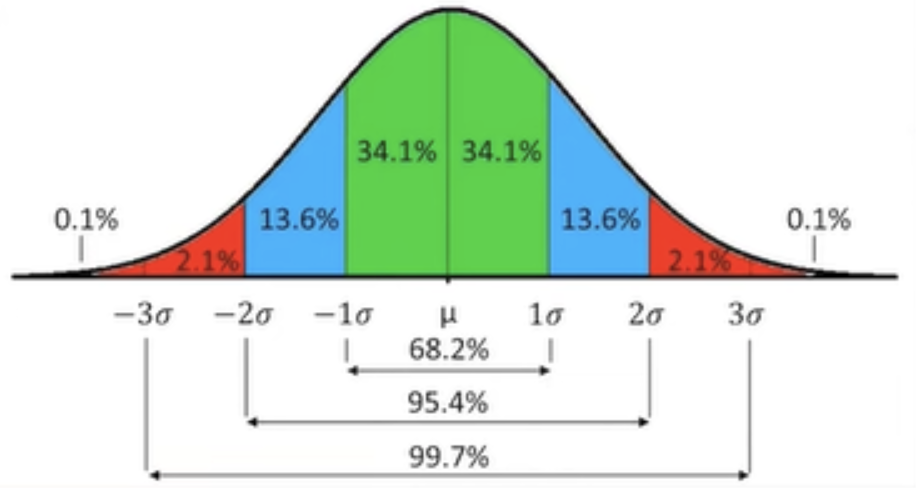

If mean is <= or >= 3 sigma that means you have outliers. This technique is applicable when your data is normal distributed or close to normal distributed.

### skewed distribution

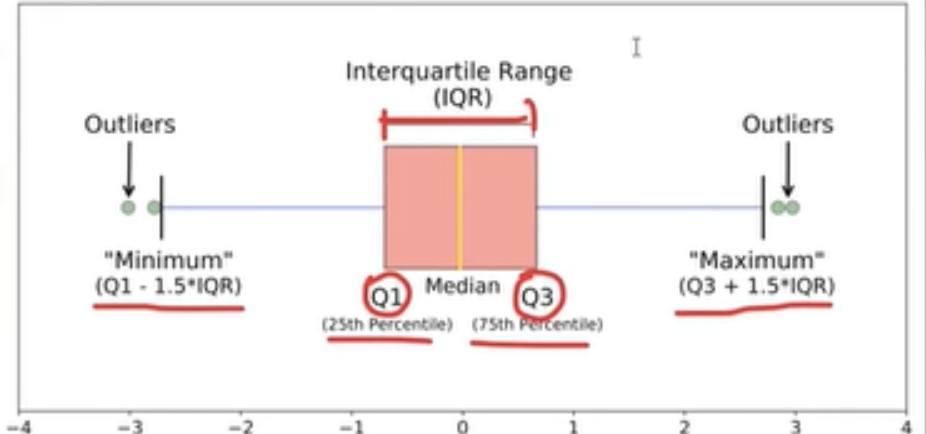

## Z score

Z-score tells us how far a value is from the average (mean).

It assumes data is
- Normally distributed (bell curve)
- Symmetric

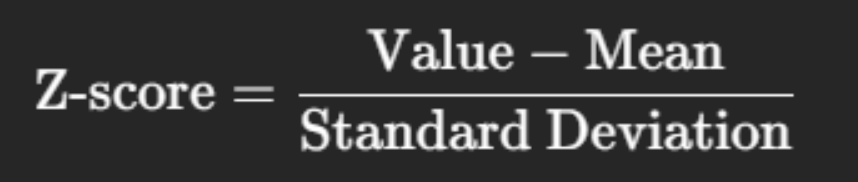

# Code Example

- Step 1 is check your data is normllay distributed or near to distributed.
- Step 2 is find out mean + 3 standard deviation or mean -3 standard deviation.
- Step 3 is decide you want to trim(cut values) or capping(replace with maximum or minimum value with outliers).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('../datasets/placement.csv')

In [9]:
df.shape

(1000, 3)

In [10]:
df.sample(5)

,cgpa,placement_exam_marks,placed
321,6.82,47.0,0
187,6.63,10.0,1
326,7.54,13.0,0
533,7.19,15.0,0
854,5.83,68.0,1


## Step 1 Checking distribution of cgpa and placemen column

/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_5429/3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_5429/3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


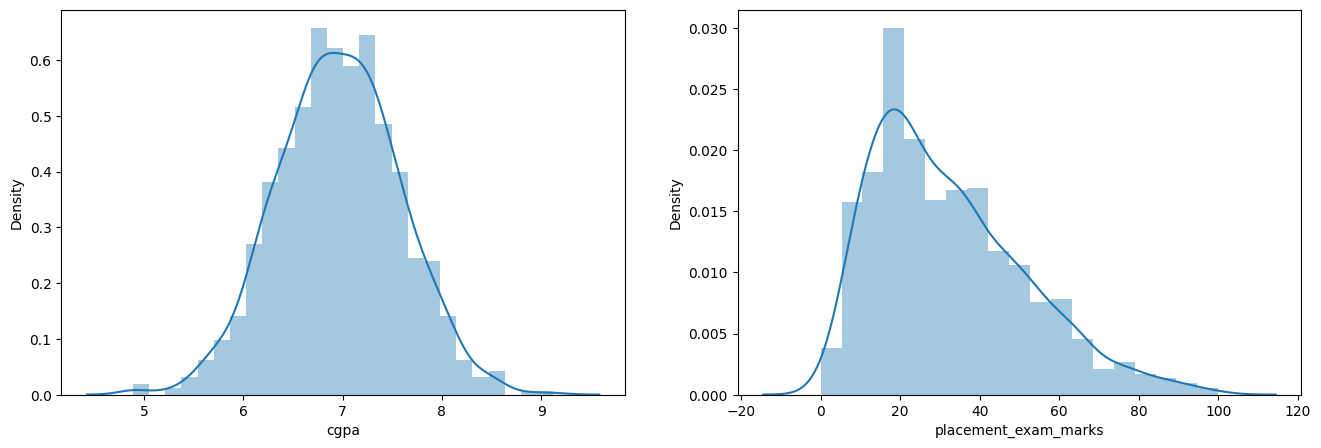

In [11]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

CGPA is normal distribution but placement column is not normal-distribution its skewed.

Now we can apply z-score on cgpa only not on placement colum.

In [12]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [13]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


## Step 2 find out mean + 3 standard deviation or mean -3 standard deviation.

In [14]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


means findig boundries if cgpa is higher than 8 is outlier and lower 5 is also outliers

In [15]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Removing Outliers

### By Trimmig method

In [17]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


### By Z-score

Z-score: Each value subtract with mean value and divide with standard deviation.

In [18]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [19]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [20]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [21]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [22]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [23]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [24]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping

In [28]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [29]:
lower_limit

5.113546374602832

In [30]:
upper_limit

8.808933625397168

In [31]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

np.where we provide 3 things:
1. x condition.
2. y if value is true so from which value should replace.
3. z if condition is false so what we do.

In [32]:
df.shape

(1000, 4)

In [33]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64